In [1]:
# === Baseline Decision Tree (tanpa tuning) ===
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score
)
import seaborn as sns
import matplotlib.pyplot as plt



In [2]:
X_train = pd.read_csv('X_train_ohe_int.csv')
X_test = pd.read_csv('X_test_ohe_int.csv')
y_train = pd.read_csv('y_train.csv').values.ravel()
y_test = pd.read_csv('y_test.csv').values.ravel()

In [3]:
dt = DecisionTreeClassifier(
    # Fungsi impurity untuk pemilihan split.
    # 'gini' = Gini impurity (default), alternatifnya 'entropy' (information gain).
    criterion="gini",

    # Strategi pemilihan split di tiap node:
    # 'best' memilih split terbaik, 'random' memilih split acak (kadang dipakai untuk regularisasi ringan).
    splitter="best",

    # Batas kedalaman pohon. None = tumbuh sampai semua daun pure → risiko overfitting.
    # Karena ini baseline, biarkan None dulu (nanti di tuning bisa kita batasi).
    max_depth=None,

    # Minimal jumlah sampel untuk melakukan split sebuah node (default=2).
    # Nilai lebih besar = pohon lebih “hemat” (regularisasi), kurangi overfit.
    min_samples_split=2,

    # Minimal jumlah sampel di sebuah leaf/daun (default=1).
    # Naikkan nilai ini saat tuning untuk mengurangi overfit dan smoothing prediksi.
    min_samples_leaf=1,

    # Jumlah fitur yang dipertimbangkan saat mencari split terbaik.
    # None = semua fitur (default). Saat tuning bisa coba 'sqrt' atau 'log2'.
    max_features=None,

    # Menangani imbalance 3:1. 'balanced' memberi bobot ∝ 1/frekuensi kelas.
    # Ini penting agar pohon tidak terlalu condong ke kelas mayoritas.
    class_weight="balanced",

    # Random seed untuk reprodusibilitas (mempengaruhi tie-break, urutan data, dsb).
    random_state=42
)

In [4]:
# --- 3) Training ---
dt.fit(X_train, y_train.ravel())

DecisionTreeClassifier(class_weight='balanced', random_state=42)

In [5]:

# --- 4) Prediksi & evaluasi ---
y_pred = dt.predict(X_test)

In [6]:
# Probabilitas (dipakai untuk ROC-AUC)
# NB: Decision Tree menghasilkan probabilitas via proporsi kelas di daun.
y_proba = dt.predict_proba(X_test)[:, 1]

# Confusion matrix (format default: baris=aktual, kolom=prediksi; urutan label [0,1])
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

print("Classification Report (Decision Tree Baseline):")
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

Classification Report (Decision Tree Baseline):
              precision    recall  f1-score   support

    No Churn       0.84      0.77      0.80      1033
       Churn       0.48      0.59      0.53       374

    accuracy                           0.72      1407
   macro avg       0.66      0.68      0.67      1407
weighted avg       0.74      0.72      0.73      1407



In [7]:
roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC: {roc_auc:.4f}")

ROC-AUC: 0.6866


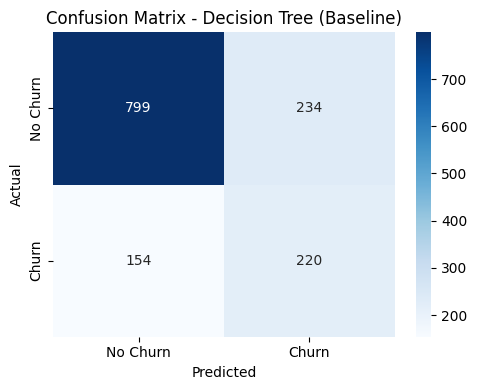

In [8]:
# --- 5) Plot confusion matrix (gaya sebelumnya) ---
plt.figure(figsize=(5,4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=['No Churn', 'Churn'],  # kolom = Prediksi
    yticklabels=['No Churn', 'Churn']   # baris  = Aktual
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree (Baseline)")
plt.tight_layout()
plt.show()
